## Project Title: Customer Churn Analysis and Prediction

### Project Overview:The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers. The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve customer retention.

In [1]:
#import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Task 1: Data Preparation

Description:In this task, you will be responsible for loading
the dataset and conducting an initial
exploration. Handle missing values, and if
necessary, convert categorical variables into
numerical representations. Furthermore, split
the dataset into training and testing sets for
subsequent model evaluation.

In [2]:
# load dataset
df = pd.read_csv('Telco_Customer_Churn.csv')

In [3]:
#set full preview
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#total charges unique
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [6]:
#convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# show nan value total cherges 2
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No




*   tenure = 0  meaning the customer just joined and was likely billed 0 so far.

*   Their TotalCharges is blank  which makes sense, as they haven’t been billed yet.



*   thats why we fill nan value with 0




In [9]:
# totalcharges fill nan value with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# drop custmer id beacuse its unnessary
df.drop('customerID', axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [13]:
#gender unique
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [14]:
#unie value all object column
for col in df.columns:
  print(f'{col}: {df[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalChar

In [15]:
# male 1 and female 0 encoding
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [16]:
#  partner column yes 1 and no 0
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})

In [17]:
# phone service no 0, yes 1
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})

In [18]:
#multiple line no phone serviece 0 , no 0 yes 1
df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})

In [19]:
#internet service DSL 2, fiber optic 1, no 0
df['InternetService'] = df['InternetService'].map({'DSL': 2, 'Fiber optic': 1, 'No': 0})

In [20]:
# dependent no 0 yes 1
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})

In [21]:
#onlion security no 0, no internet service 0 yes 1
df['OnlineSecurity'] = df['OnlineSecurity'].map({'No': 0, 'No internet service': 0, 'Yes': 1})

In [22]:
#same do onlionbackup,deviceprotection,techsupport and stemingtv
df['OnlineBackup'] = df['OnlineBackup'].map({'No': 0, 'No internet service': 0, 'Yes': 1})
df['DeviceProtection'] = df['DeviceProtection'].map({'No': 0, 'No internet service': 0, 'Yes': 1})
df['TechSupport'] = df['TechSupport'].map({'No': 0, 'No internet service': 0, 'Yes': 1})
df['StreamingTV'] = df['StreamingTV'].map({'No': 0, 'No internet service': 0, 'Yes': 1})

In [23]:
df['StreamingMovies'] = df['StreamingMovies'].map({'No': 0, 'No internet service': 0, 'Yes': 1})

In [24]:
#peperless billing no 0 yes 1
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No': 0, 'Yes': 1})

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


## Task 2: Exploratory Data Analysis (EDA)

Description:
Calculate and visually represent the overall
churn rate. Explore customer distribution by
gender, partner status, and dependent status.
Analyze tenure distribution and its relation
with churn. Investigate how churn varies
across different contract types and payment
methods.

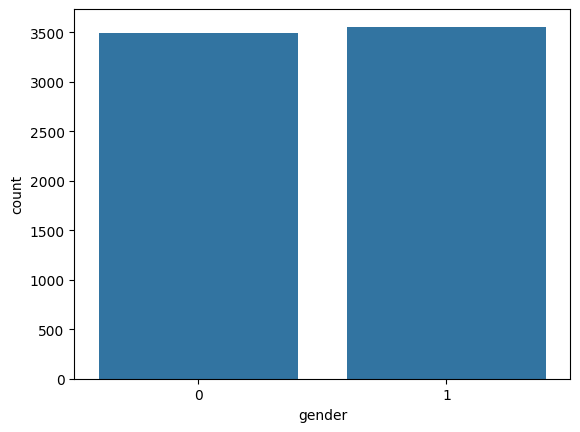

In [26]:
# gender distribution count plot
sns.countplot(x='gender', data=df)
plt.show()

- it will show both male and female are equal costumer distibution

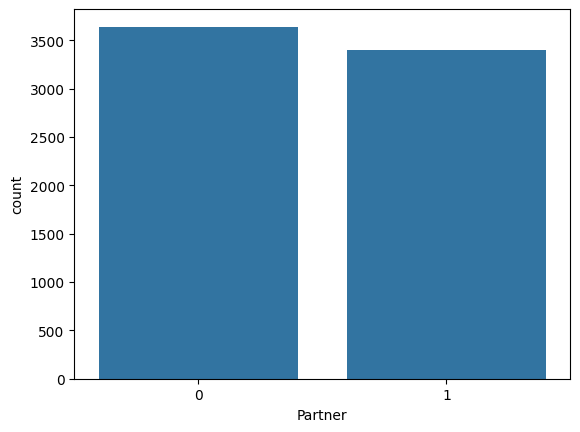

In [27]:
#partner and depent count plot
sns.countplot(x='Partner', data=df)
plt.show()

- more customre has no parner but its minor or negligible change

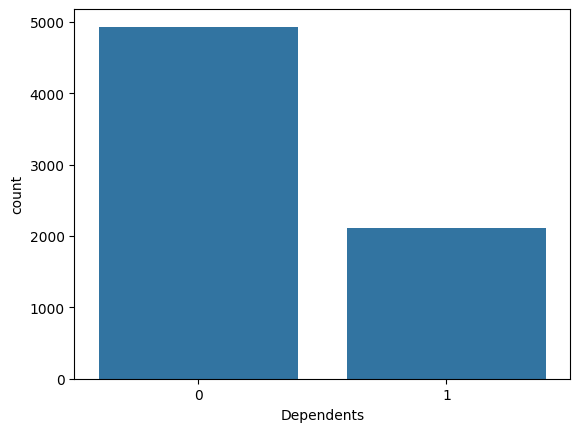

In [28]:
sns.countplot(x='Dependents', data=df)
plt.show()

- more customer has no dependet means its alone as compare to dependent (family)

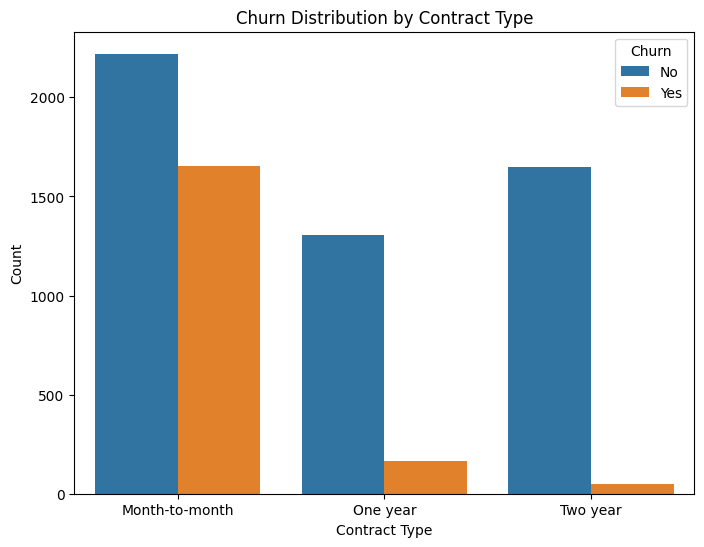

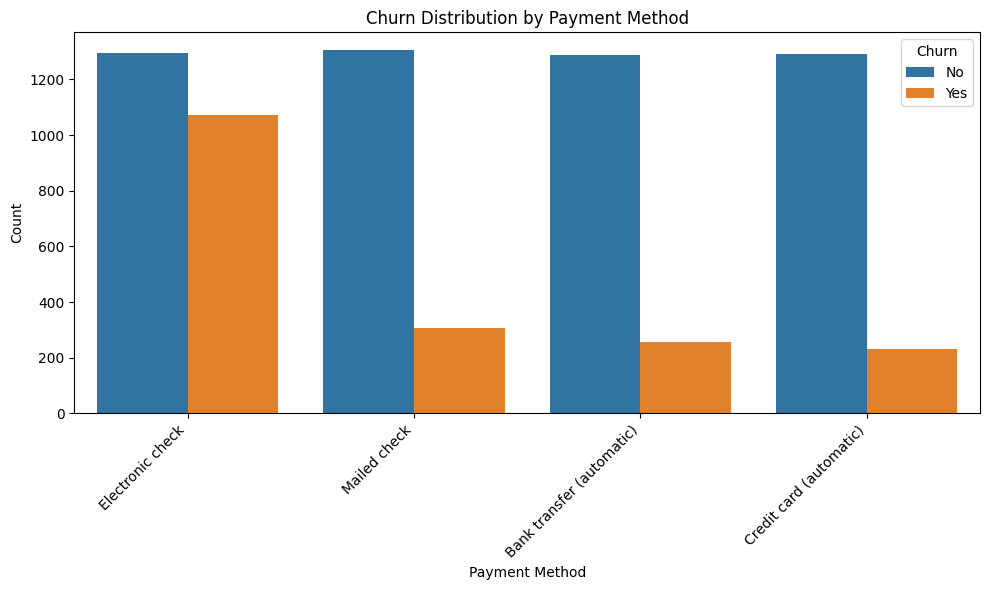

In [29]:
# Contract type and Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Payment method and Churn
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- by payment method electrock check has high churan and month to minth contact also high curan customer mean left the costomer or not active while others perameter are moderate

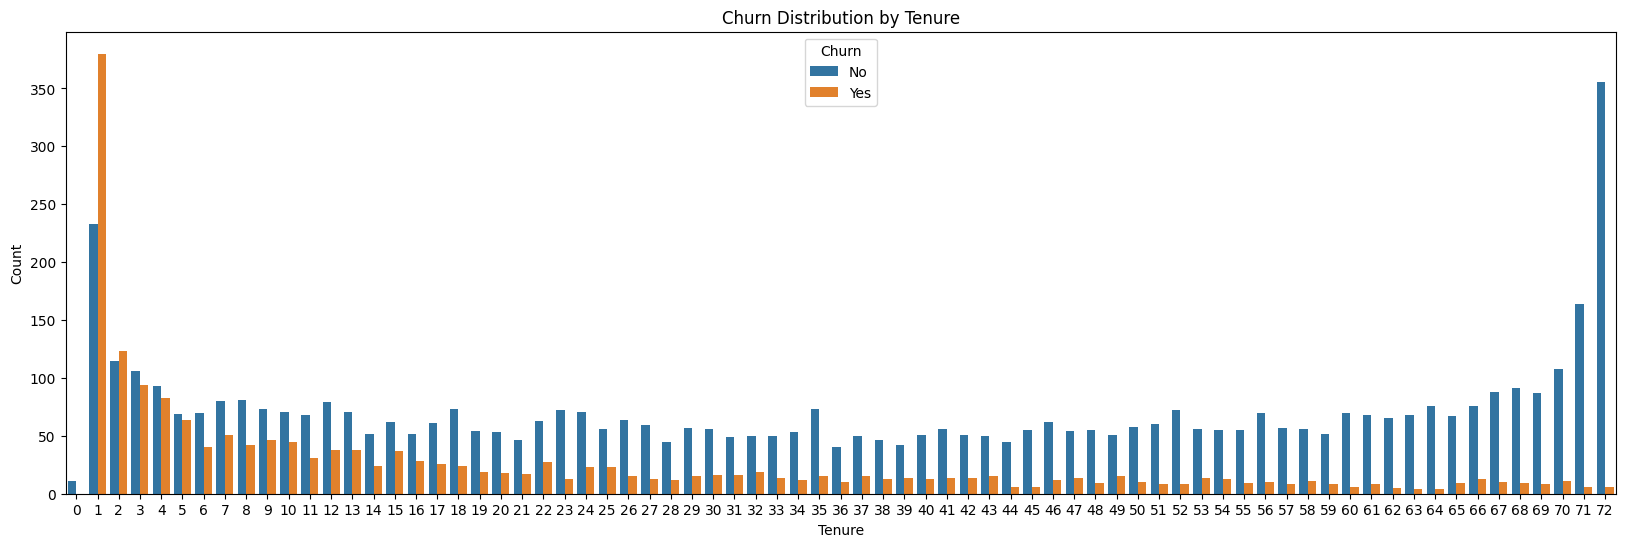

In [30]:
# tenture and churan count plot
plt.figure(figsize=(20, 6))
sns.countplot(x='tenure', hue='Churn', data=df)
plt.title('Churn Distribution by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

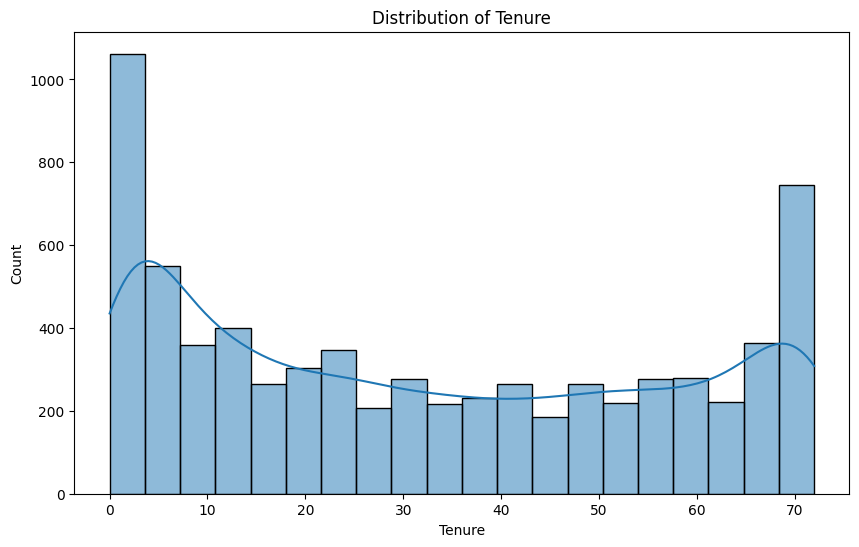

In [31]:
# tenture distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], bins=20, kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.show()

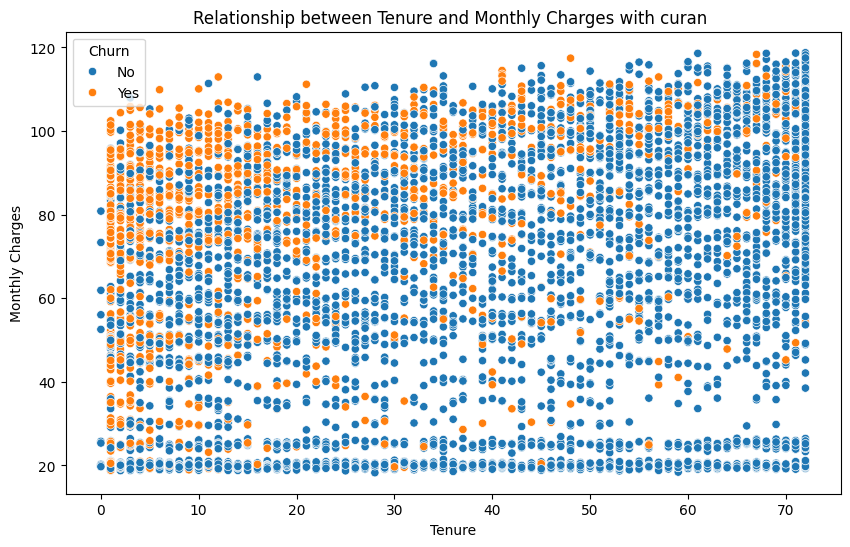

In [32]:
# scatter plot curan and tenture
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.title('Relationship between Tenure and Monthly Charges with curan ')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.show()

1. Big Spike at Tenure = 0-5 Months
- There's a large concentration of new customers (0-5 months).
- Indicates many customers sign up but churn early.
- Interpretation: These are likely high-risk customers with low loyalty or dissatisfaction soon after joining.

2. Fairly Even Mid-Tenure (10-60 Months)
- Distribution is more uniform between 10 to 60 months.
- Lower counts, but still stable customer base in this range.
- Interpretation: These are moderately engaged users — churn is lower, but still possible.

3. Another Spike at 70-72 Months
- A second peak appears at the very end of the tenure range.
- These are long-term customers, likely with contracts or higher satisfaction.
- Interpretation: These users are very loyal — less likely to churn.

## **Recommendations**

**Focus churn-prevention strategies on the 0–5 month group:Onboarding, support, promotions, early feedback collection.**

**Retention programs for 5–15 month users to keep them from drifting.**

**Long-term customers (70+ months) can be used for loyalty case studies or upselling.**

In [33]:
# churan yes 1 no 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


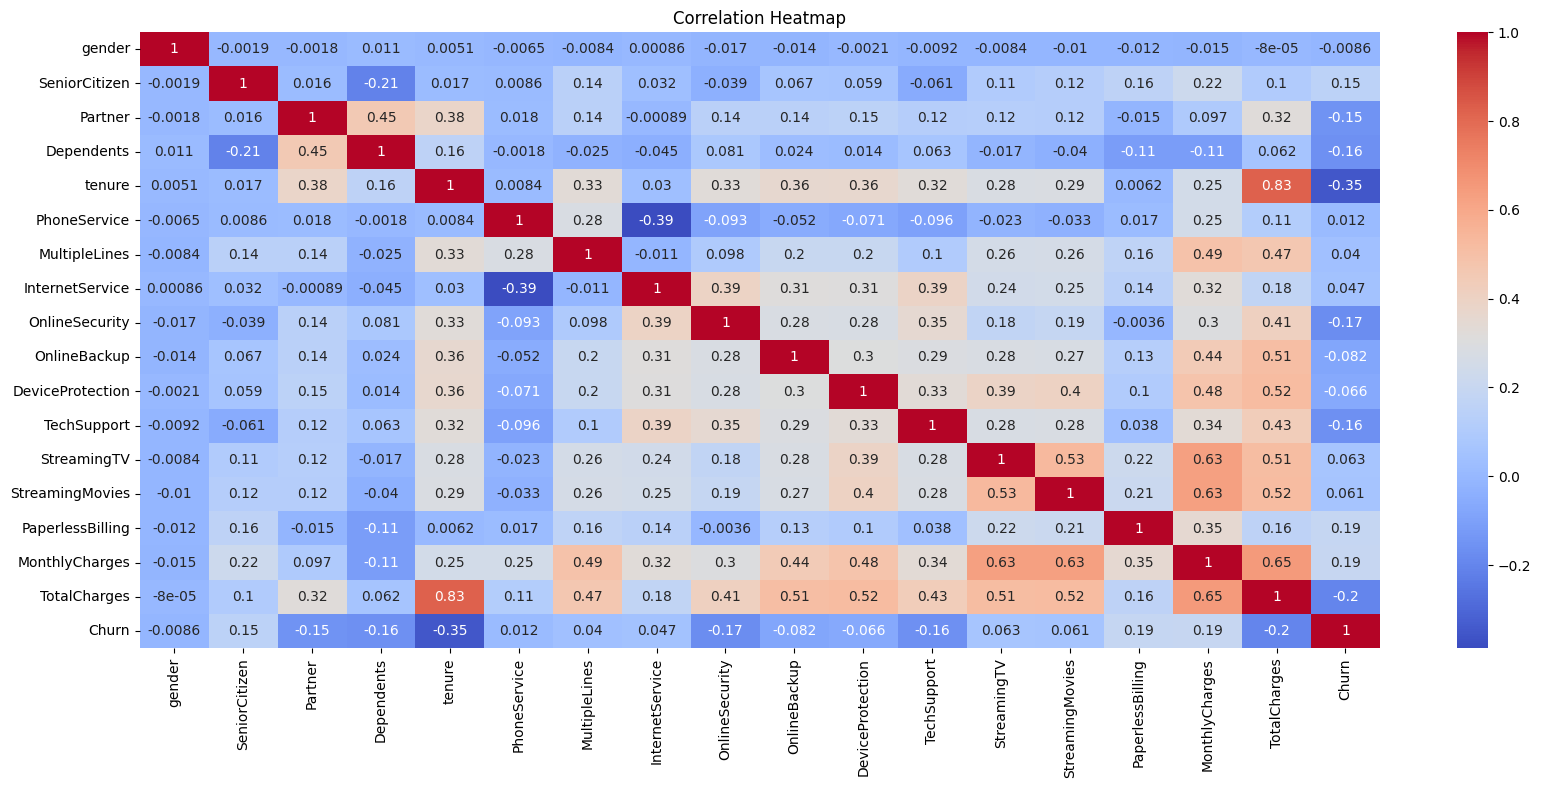

In [35]:
#coretion heat map
num_col = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(20, 8))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [36]:
# vif check
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
X = sm.add_constant(df[num_col])
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
#print
print(vif)

            Variable        VIF
0              const  31.452109
1             gender   1.001606
2      SeniorCitizen   1.147228
3            Partner   1.460195
4         Dependents   1.375599
5             tenure   6.098955
6       PhoneService   1.709524
7      MultipleLines   1.543142
8    InternetService   1.888020
9     OnlineSecurity   1.479263
10      OnlineBackup   1.519002
11  DeviceProtection   1.568491
12       TechSupport   1.479036
13       StreamingTV   1.909367
14   StreamingMovies   1.914085
15  PaperlessBilling   1.198609
16    MonthlyCharges   6.372728
17      TotalCharges  10.573716
18             Churn   1.373943


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


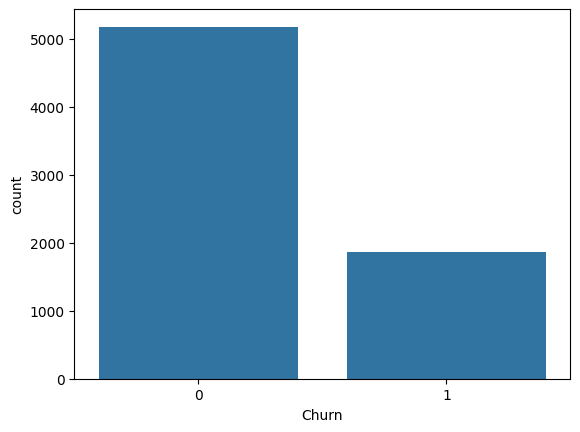

In [38]:
# count plot churan
sns.countplot(x='Churn', data=df)
plt.show()

In [39]:
# percentage of churan
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


- its show number of customer has loyan and active 73% and 26% of customer has churan

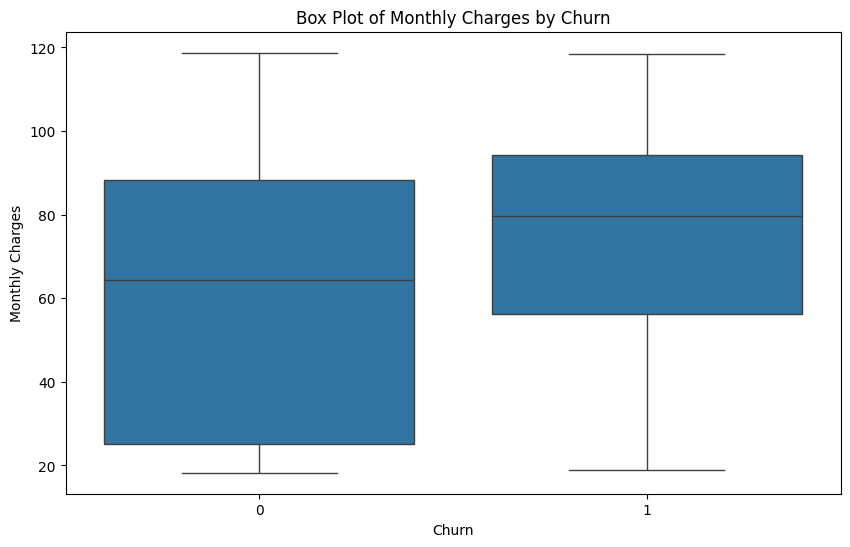

In [40]:
#box plot to churan
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Box Plot of Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

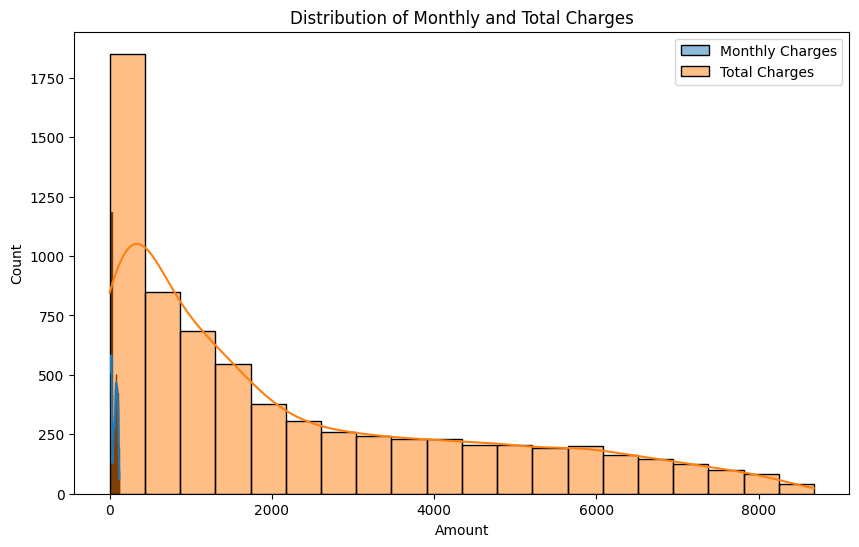

In [41]:
# montlt charger and total charge histograme
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=20, kde=True, label='Monthly Charges')
sns.histplot(df['TotalCharges'], bins=20, kde=True, label='Total Charges')
plt.title('Distribution of Monthly and Total Charges')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.show()

In [42]:
# Cramér's V  for categorical feture
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    # Correct the function name from chi2_con to chi2_contingency
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
#use case
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    cramers_v_score = cramers_v(df[col], df['Churn'])
    print(f'Cramer\'s V score for {col}: {cramers_v_score}')

Cramer's V score for Contract: 0.40979839182553446
Cramer's V score for PaymentMethod: 0.3026771381187204


Contract: 0.41
- Strong correlation with churn.
- Customers with Month-to-month contracts likely churn more than those on One or Two year contracts.
- Actionable Insight: Encourage longer-term contracts to reduce churn.

PaymentMethod: 0.30
- Moderate to strong correlation.
- Likely that people using Electronic check churn more (often seen in telco datasets).
- Actionable Insight: Promote auto-pay or credit card for more stable billing.

In [43]:
# contract unique
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [44]:
# contarct month to month 1, one year 12, two year 24
df['Contract'] = df['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

In [45]:
# payment method uniqu
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [46]:
# Electronic check' 1 , 'Mailed check' 2 , 'Bank transfer(automatic) 3 'Credit card (automatic)' 4
df['PaymentMethod'] = df['PaymentMethod'].map({'Electronic check': 1, 'Mailed check': 2, 'Bank transfer (automatic)': 3, 'Credit card (automatic)': 4})

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [48]:
# corrtion heaad map repect to curan
df.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV,0.063228
StreamingMovies,0.061382
InternetService,0.047291
MultipleLines,0.040102
PhoneService,0.011942
gender,-0.008612


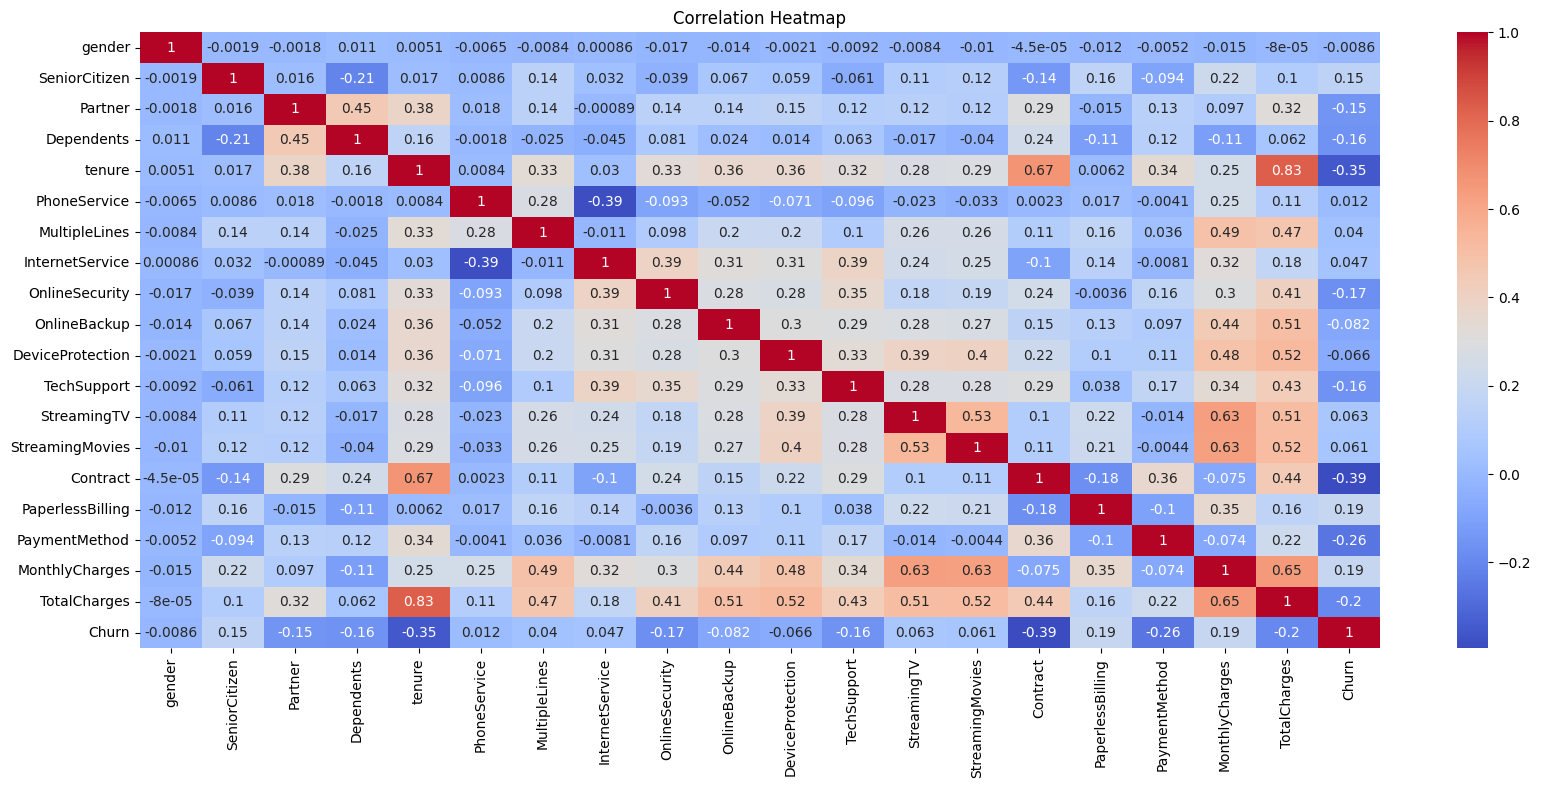

In [49]:
# heat map
plt.figure(figsize=(20, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Task 3: Customer Segmentation

Description:
Segment customers based on tenure,
monthly charges, and contract type. Analyze
churn rates within these segments. Identify
high-value customers who are at risk of
churning and might need special attention.

In [50]:
df1 = df.copy()

In [51]:
def segment_tenure(tenure):
    if tenure <= 12:
        return 'New'
    elif tenure <= 48:
        return 'Mid-term'
    else:
        return 'Long-term'

df1['TenureSegment'] = df1['tenure'].apply(segment_tenure)

In [52]:
def segment_charges(charges):
    if charges < 35:
        return 'Low'
    elif charges <= 70:
        return 'Medium'
    else:
        return 'High'

df1['ChargeSegment'] = df1['MonthlyCharges'].apply(segment_charges)

In [53]:
# revese chage to original contract map
df1['Contract'] = df1['Contract'].map({1: 'Month-to-month', 12: 'One year', 24: 'Two year'})

In [54]:
df1['CustomerSegment'] = (
    df1['TenureSegment'] + ' | ' +
    df1['ChargeSegment'] + ' | ' +
    df1['Contract'])

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [56]:
segment_summary = df1.groupby('CustomerSegment').agg(
    Total_Customers=('gender', 'count'),
    Churned=('Churn', lambda x: (x == 1).sum())
)

segment_summary['ChurnRate (%)'] = round(
    (segment_summary['Churned'] / segment_summary['Total_Customers']) * 100, 2
)

segment_summary = segment_summary.sort_values(by='ChurnRate (%)', ascending=False)

# Preview the segment churn summary
segment_summary.head()

,Total_Customers,Churned,ChurnRate (%)
CustomerSegment,,,
New | High | Month-to-month,856,591,69.04
New | Medium | Month-to-month,631,286,45.32
Mid-term | High | Month-to-month,969,436,44.99
New | Low | Month-to-month,507,147,28.99
Long-term | High | Month-to-month,272,78,28.68


In [57]:
segment_summary

,Total_Customers,Churned,ChurnRate (%)
CustomerSegment,,,
New | High | Month-to-month,856,591,69.04
New | Medium | Month-to-month,631,286,45.32
Mid-term | High | Month-to-month,969,436,44.99
New | Low | Month-to-month,507,147,28.99
Long-term | High | Month-to-month,272,78,28.68
Mid-term | Medium | Month-to-month,381,83,21.78
New | High | One year,14,3,21.43
Mid-term | High | One year,270,48,17.78
New | Medium | One year,29,5,17.24


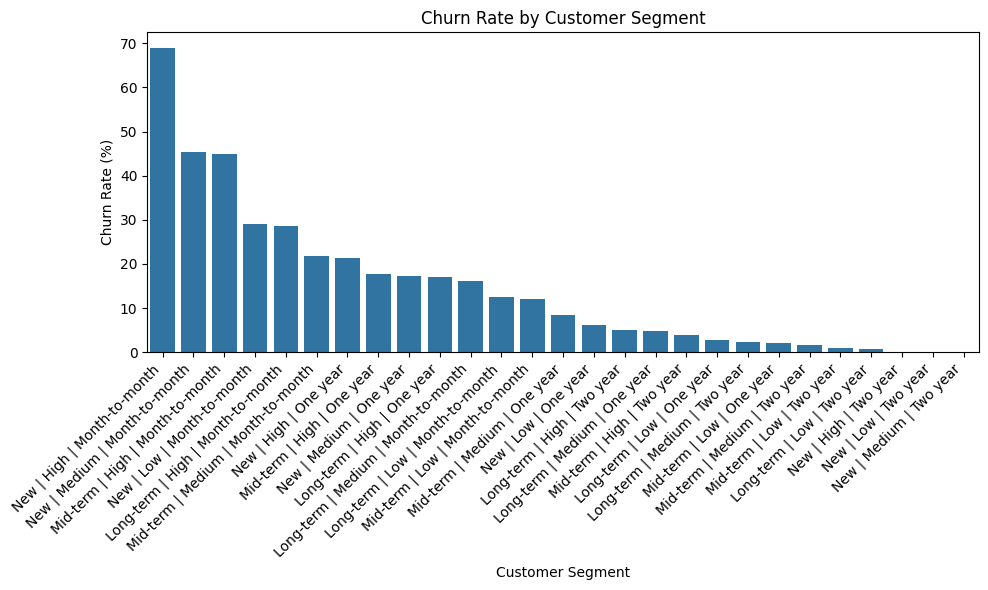

In [58]:
# bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_summary.index, y='ChurnRate (%)', data=segment_summary.reset_index())
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


 **New + High Spend + Month-to-Month = Most Dangerous Combo( High-Risk Segments)**
- These customers churn at 69% — they just joined, pay a lot, and haven’t committed long-term.
- These are high-value, high-risk customers — critical to retain!

 ** Mid-Term + High Spend also risky**
- At ~45%, they are still not stable even after a year or two.
- They might be shopping around or unhappy despite being high spenders.

 ** Long-term + High Spend are much more loyal(Medium-Risk Segments)**
- Only 28% churn rate — suggests contract type or time builds trust.
- Loyal but not fully secure (e.g., long-term users without contracts),
- Or new but low value, so not high-priority unless they upgrade.

Focus on:
- Upselling mid-tier customers.
- Offering loyalty points or bonuses to long-term month-to-month users

** Low-Risk Segments (<20%) **
- These are mostly:Two-year contract holders, or Long-tenured customers with any contractOr even new users on two-year plans — zero churn here


# Retention Strategy
1.  “New | High | Month-to-month”:
- Welcome loyalty perks or discounts within first 3 months
- Proactive customer support check-ins
- Offer incentives to switch to longer contracts

2. For Mid-Term High Spenders:
- Analyze feedback/complaints if available
- Use personalized offers or upgrades
- Target with smart churn-predictive campaigns

## Task 4: Churn Prediction Model

Description:
Choose suitable machine learning algorithms
(e.g., logistic regression, decision trees) for
churn prediction. Split data into training and
testing sets, train and evaluate multiple
models using metrics like accuracy, precision,
recall, and F1-score. Perform feature selection
and hyperparameter tuning for optimal
performance.

we do here both task 4 and 5

## Task 5: Model Evaluation and Interpretation

Description:
Evaluate the best predictive model using the
testing dataset. Interpret model coefficients or
feature importances to comprehend factors
influencing churn. Create ROC curves and
calculate AUC for model performance
assessment.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [60]:
# import classifier algorithm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

In [61]:
# x and y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [62]:
# Scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# build randomforestclassfier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

#predict
y_pred = rf_classifier.predict(X_test)

# evalution
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# print
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(cm)


Accuracy: 0.794889992902768
Precision: 0.6555555555555556
Recall: 0.4745308310991957
F1 Score: 0.5505443234836703
[[943  93]
 [196 177]]



--- Evaluation on Training Set ---
Train Accuracy: 0.9985800496982605
Train Precision: 0.9973262032085561
Train Recall: 0.9973262032085561
Train F1 Score: 0.9973262032085561

--- Evaluation on Testing Set ---
Test Accuracy: 0.794889992902768
Test Precision: 0.6555555555555556
Test Recall: 0.4745308310991957
Test F1 Score: 0.5505443234836703

--- Overfitting Check ---
Accuracy Difference (Train - Test): 0.20369005679549257
Precision Difference (Train - Test): 0.3417706476530006
Recall Difference (Train - Test): 0.5227953721093604
F1 Score Difference (Train - Test): 0.4467818797248858

Potential Overfitting Detected: Training metrics are significantly higher than testing metrics.


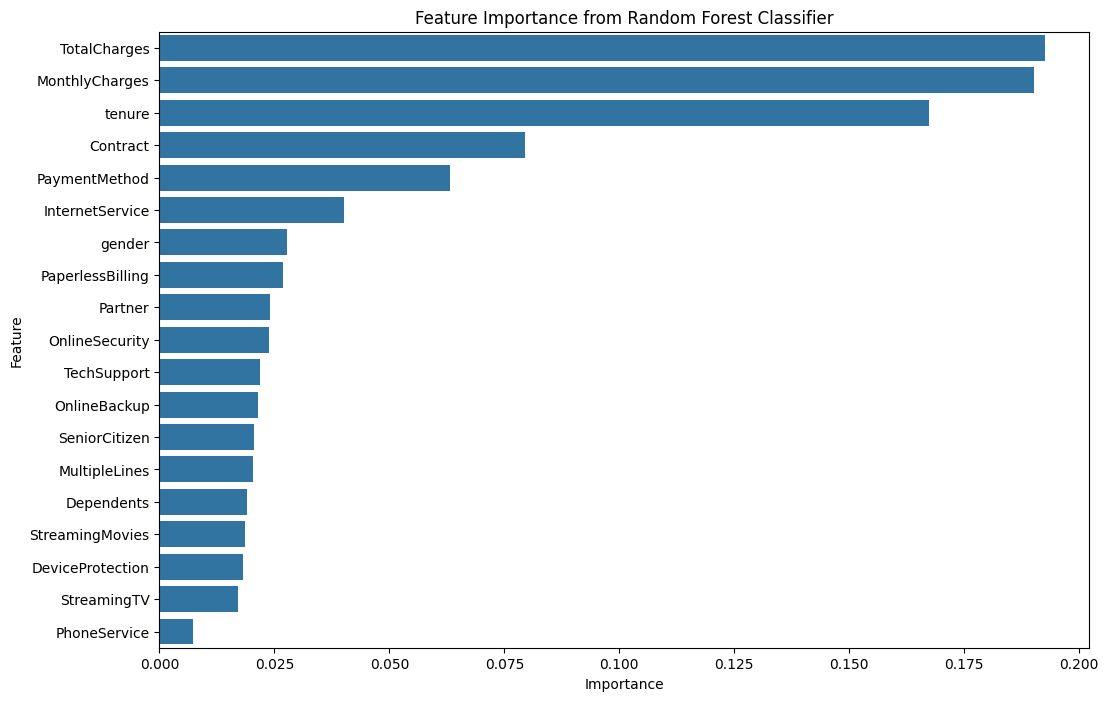

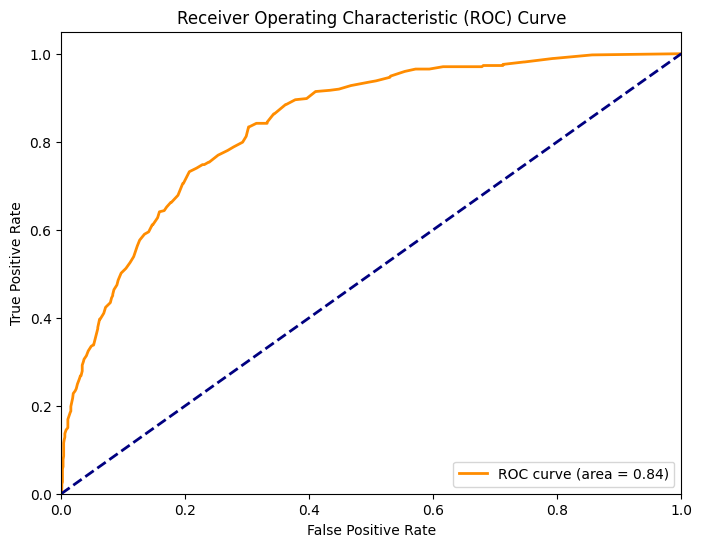

AUC: 0.8399740702019522


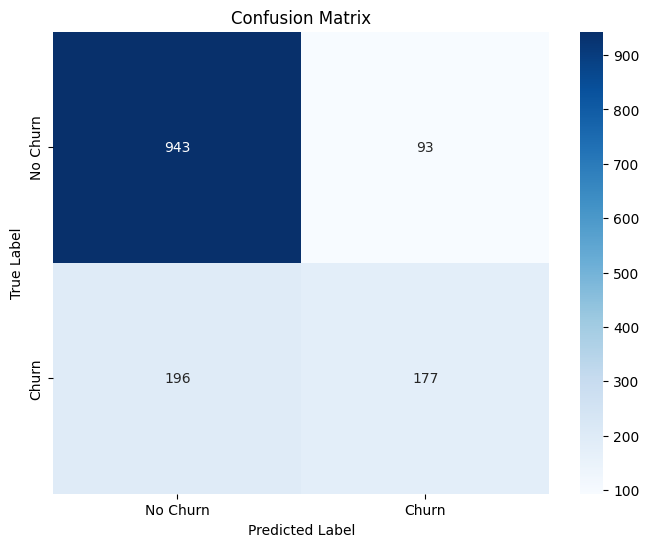

In [63]:

rf_classifier_train = RandomForestClassifier(random_state=42)
rf_classifier_train.fit(X_train, y_train)
y_train_pred = rf_classifier_train.predict(X_train)

# Evaluate on training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("\n--- Evaluation on Training Set ---")
print(f'Train Accuracy: {train_accuracy}')
print(f'Train Precision: {train_precision}')
print(f'Train Recall: {train_recall}')
print(f'Train F1 Score: {train_f1}')

# Evaluate on testing set (using the model trained on training data)
y_test_pred = rf_classifier_train.predict(X_test)

# Evaluate on testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\n--- Evaluation on Testing Set ---")
print(f'Test Accuracy: {test_accuracy}')
print(f'Test Precision: {test_precision}')
print(f'Test Recall: {test_recall}')
print(f'Test F1 Score: {test_f1}')

# Check for overfitting by comparing training and testing metrics
print("\n--- Overfitting Check ---")
print(f'Accuracy Difference (Train - Test): {train_accuracy - test_accuracy}')
print(f'Precision Difference (Train - Test): {train_precision - test_precision}')
print(f'Recall Difference (Train - Test): {train_recall - test_recall}')
print(f'F1 Score Difference (Train - Test): {train_f1 - test_f1}')

if (train_accuracy - test_accuracy) > 0.1 or \
   (train_precision - test_precision) > 0.1 or \
   (train_recall - test_recall) > 0.1 or \
   (train_f1 - test_f1) > 0.1:
    print("\nPotential Overfitting Detected: Training metrics are significantly higher than testing metrics.")
else:
    print("\nNo significant overfitting detected: Training and testing metrics are relatively close.")

# Feature Importance
feature_importances = pd.Series(rf_classifier_train.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# ROC Curve and AUC
y_prob = rf_classifier_train.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f'AUC: {auc}')

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [64]:
# buld more algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from xgboost import XGBClassifier, XGBRegressor
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [65]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(results_df)

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.821150   0.682779  0.605898  0.642045
5             Naive Bayes  0.765791   0.540037  0.777480  0.637363
4  Support Vector Machine  0.811923   0.698529  0.509383  0.589147
2           Random Forest  0.801987   0.672794  0.490617  0.567442
6                 XGBoost  0.784244   0.610932  0.509383  0.555556
3     K-Nearest Neighbors  0.763662   0.558824  0.509383  0.532959
1           Decision Tree  0.738112   0.505319  0.509383  0.507343


In [70]:
# Grid serch cv
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

logreg_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

logreg_model = LogisticRegression(max_iter=1000, random_state=42)

logreg_grid = GridSearchCV(logreg_model, logreg_params, cv=5, scoring='f1')
logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression Params:", logreg_grid.best_params_)
best_logreg = logreg_grid.best_estimator_
logreg_pred = best_logreg.predict(X_test)
print(classification_report(y_test, logreg_pred))

Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.61      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [71]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_
xgb_pred = best_xgb.predict(X_test)
print(classification_report(y_test, xgb_pred))


Best XGBoost Params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Apply GridSearchCV
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Best parameters
print("Best RF Params:", rf_grid.best_params_)

# Evaluate on test data
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
print(classification_report(y_test, rf_pred))


Best RF Params: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [73]:
# train best model xgb also check overfiiting
#best model {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, colsample_bytree=1, learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.7)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
#check overfiiting
y_train_pred = xgb_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
print("\n--- Evaluation on Training Set ---")
print(f'Train Accuracy: {train_accuracy}')
print(f'Train Precision: {train_precision}')
print(f'Train Recall: {train_recall}')
print(f'Train F1 Score: {train_f1}')
print("\n--- Evaluation on Testing Set ---")
print(f'Test Accuracy: {accuracy}')
print(f'Test Precision: {precision}')
print(f'Test Recall: {recall}')
print(f'Test F1 Score: {f1}')
print("\n--- Overfitting Check ---")
print(f'Accuracy Difference (Train - Test): {train_accuracy - accuracy}')
print(f'Precision Difference (Train - Test): {train_precision - precision}')
print(f'Recall Difference (Train - Test): {train_recall - recall}')
print(f'F1 Score Difference (Train - Test): {train_f1 - f1}')

Accuracy: 0.8161816891412349
Precision: 0.6862745098039216
Recall: 0.5630026809651475
F1 Score: 0.6185567010309279

--- Evaluation on Training Set ---
Train Accuracy: 0.8198438054668087
Train Precision: 0.7043330501274426
Train Recall: 0.554144385026738
Train F1 Score: 0.6202768424990647

--- Evaluation on Testing Set ---
Test Accuracy: 0.8161816891412349
Test Precision: 0.6862745098039216
Test Recall: 0.5630026809651475
Test F1 Score: 0.6185567010309279

--- Overfitting Check ---
Accuracy Difference (Train - Test): 0.003662116325573783
Precision Difference (Train - Test): 0.018058540323521055
Recall Difference (Train - Test): -0.008858295938409477
F1 Score Difference (Train - Test): 0.0017201414681368155


In [74]:
# above same  code for logistic regressor
# best model {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
logreg_model = LogisticRegression(max_iter=1000, random_state=42, C=10, penalty='l2', solver='liblinear')
logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
# check overffiting
y_train_pred = logreg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
print("\n--- Evaluation on Training Set ---")
print(f'Train Accuracy: {train_accuracy}')
print(f'Train Precision: {train_precision}')
print(f'Train Recall: {train_recall}')
print(f'Train F1 Score: {train_f1}')
print("\n--- Evaluation on Testing Set ---")
print(f'Test Accuracy: {accuracy}')
print(f'Test Precision: {precision}')
print(f'Test Recall: {recall}')
print(f'Test F1 Score: {f1}')
print("\n--- Overfitting Check ---")
print(f'Accuracy Difference (Train - Test): {train_accuracy - accuracy}')
print(f'Precision Difference (Train - Test): {train_precision - precision}')
print(f'Recall Difference (Train - Test): {train_recall - recall}')

Accuracy: 0.8204400283889283
Precision: 0.6807228915662651
Recall: 0.6058981233243967
F1 Score: 0.6411347517730497

--- Evaluation on Training Set ---
Train Accuracy: 0.8022719204827831
Train Precision: 0.6547811993517018
Train Recall: 0.5401069518716578
Train F1 Score: 0.591941391941392

--- Evaluation on Testing Set ---
Test Accuracy: 0.8204400283889283
Test Precision: 0.6807228915662651
Test Recall: 0.6058981233243967
Test F1 Score: 0.6411347517730497

--- Overfitting Check ---
Accuracy Difference (Train - Test): -0.018168107906145203
Precision Difference (Train - Test): -0.025941692214563328
Recall Difference (Train - Test): -0.06579117145273894


- above all case XGBoost perform well in other all yes logistic refressin perform also well but its underfiiting on other hand XGboost perform well without major overfiiting or underfiiting

In [75]:
#save model pkl file XGB model
from joblib import dump
dump(xgb_model, 'xgb_model.pkl')


['xgb_model.pkl']